In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("dataset.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [3]:
df.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

# Data Cleaning

In [4]:
num_coln = df.select_dtypes(include=["number"]).columns
catg_coln = df.select_dtypes(include=["object"]).columns

from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy="mean")
catg_imp = SimpleImputer(strategy="most_frequent")

df[num_coln] = num_imp.fit_transform(df[num_coln])
df[catg_coln] = catg_imp.fit_transform(df[catg_coln])

df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

# EDA - Exploratory Data Analysis

<Figure size 1000x600 with 0 Axes>

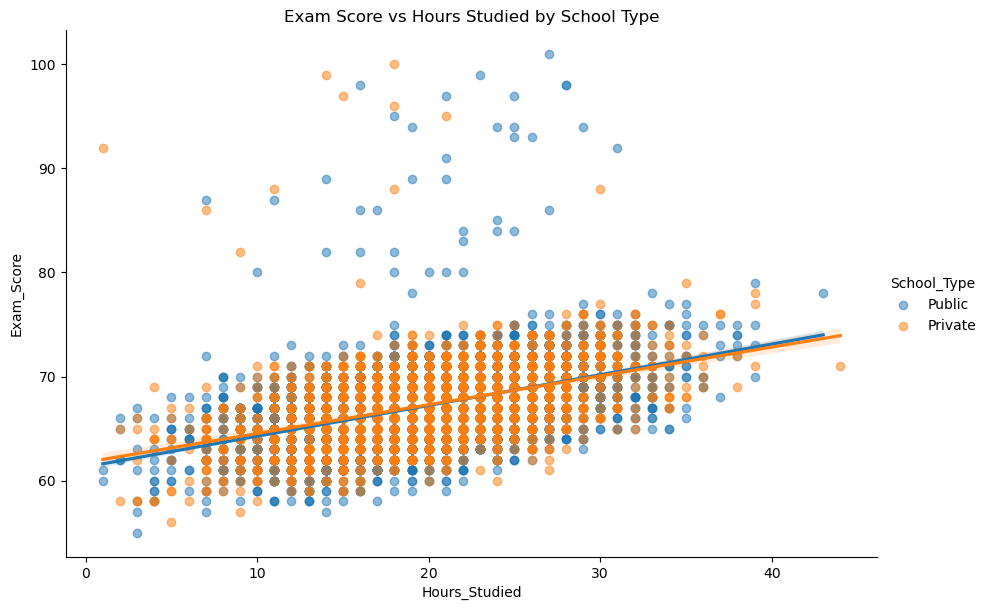

In [5]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df, x="Hours_Studied", y="Exam_Score", hue="School_Type", height=6, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title("Exam Score vs Hours Studied by School Type")
plt.show()

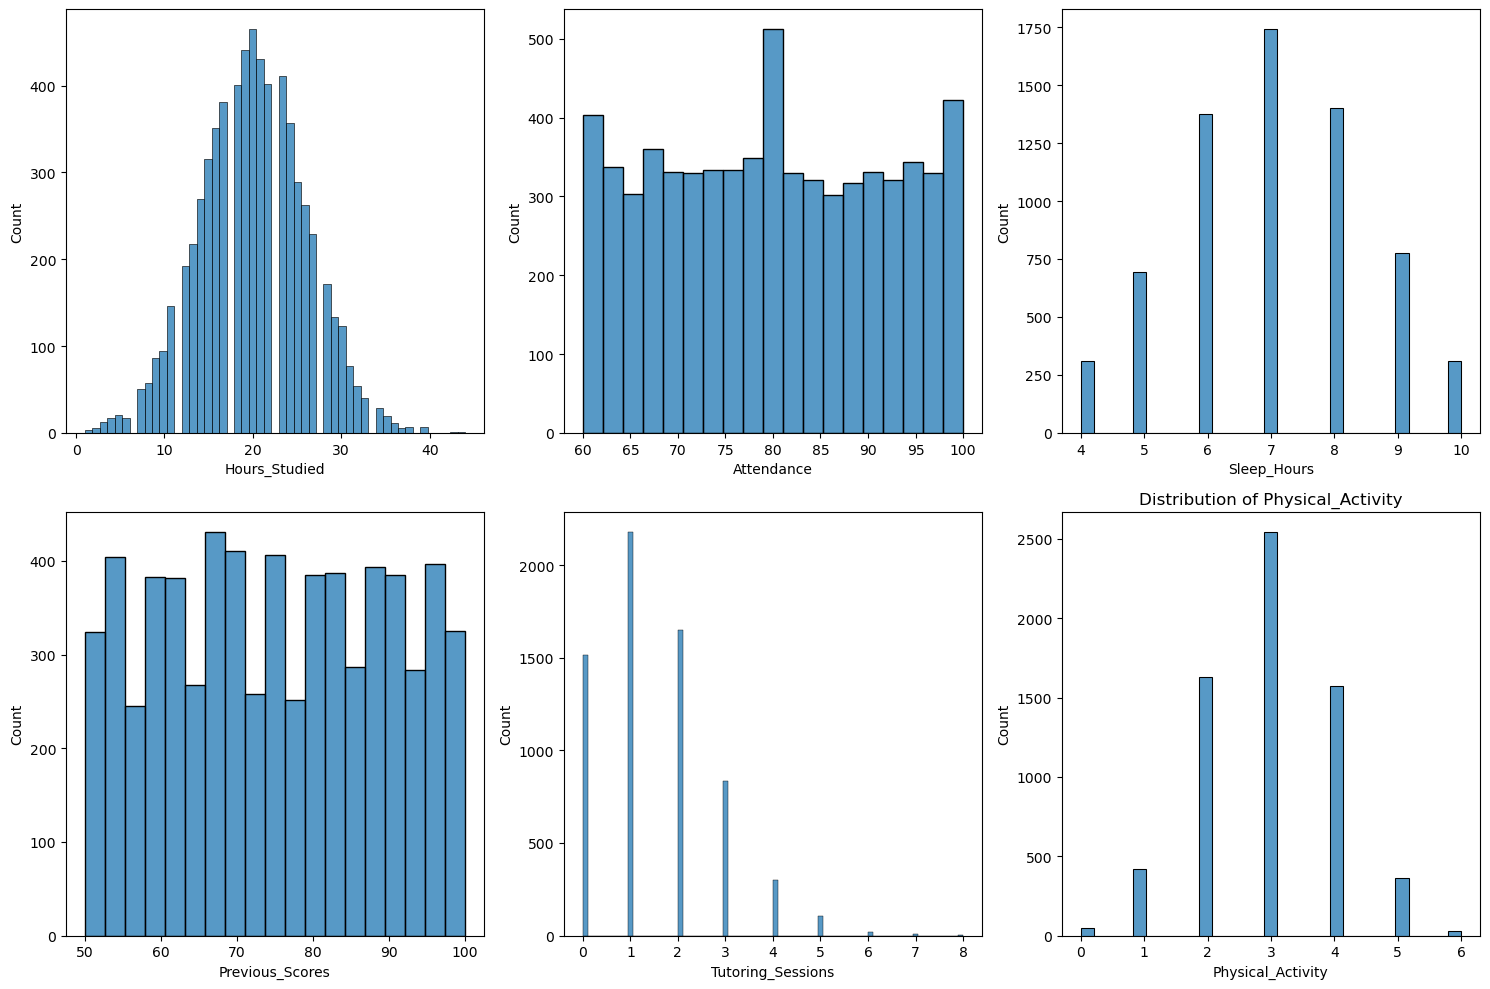

In [6]:
fig, axes = plt.subplots(2,3,figsize=(15,10))
for ax,col in zip(axes.flatten(),num_coln):
    sns.histplot(ax=ax, data=df, x=df[col])
    plt.title(f"Distribution of {col}")
plt.tight_layout()

In [7]:
df = df[df["Tutoring_Sessions"]<8]

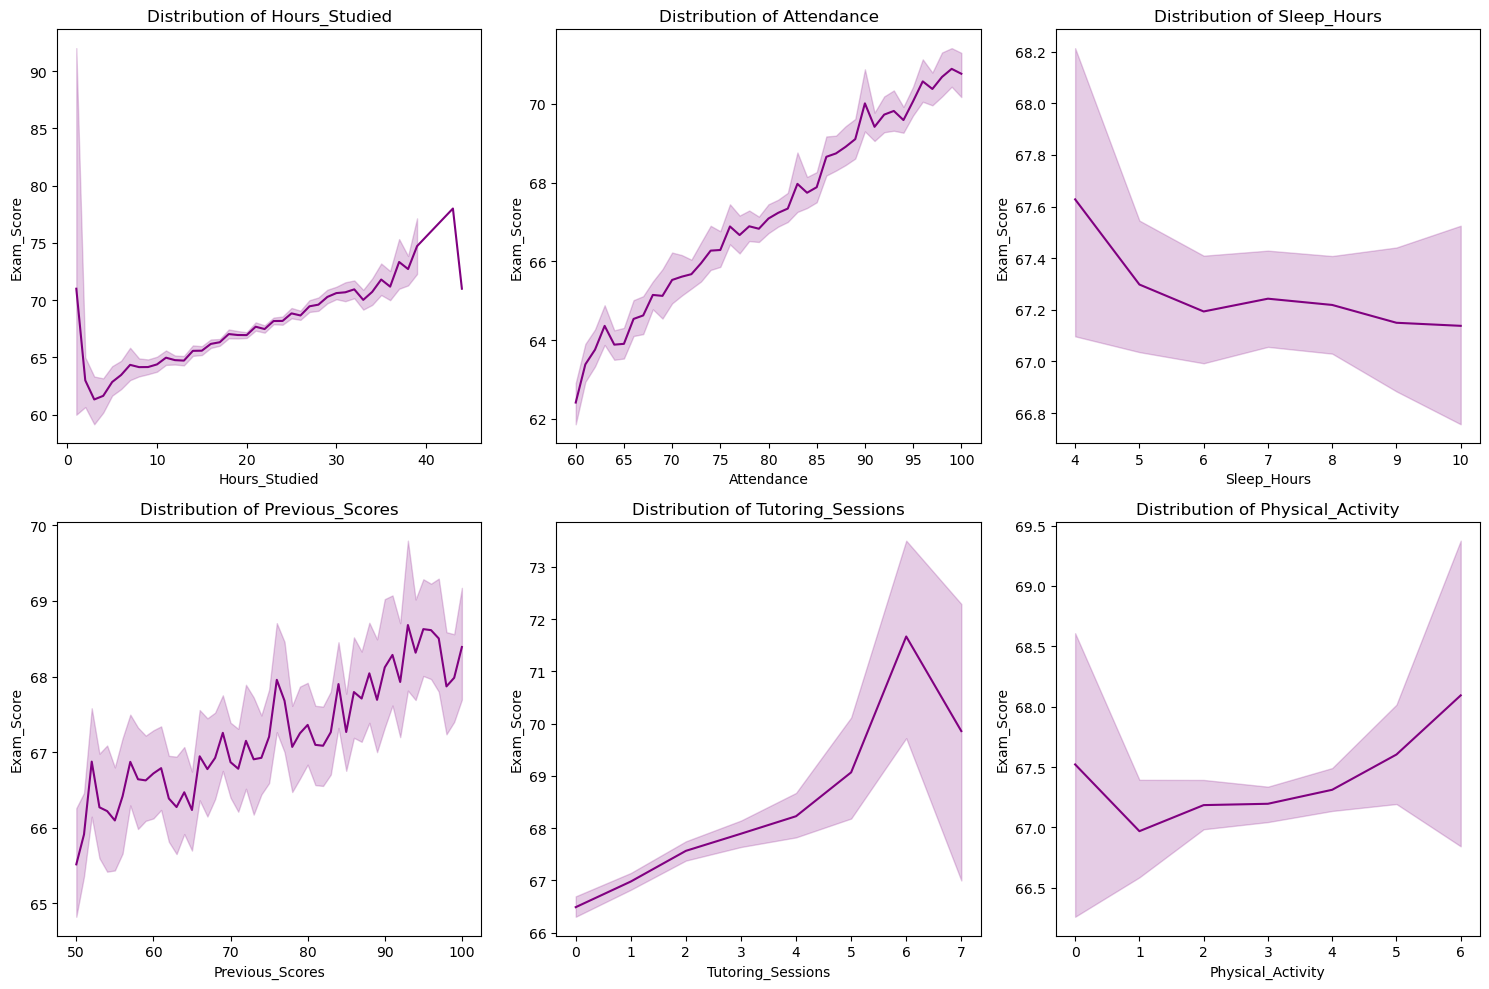

In [8]:
fig, axes = plt.subplots(2,3,figsize=(15,10))
for ax,col in zip(axes.flatten(),num_coln):
    sns.lineplot(ax=ax, data=df, x=col, y=df["Exam_Score"],color="purple")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()

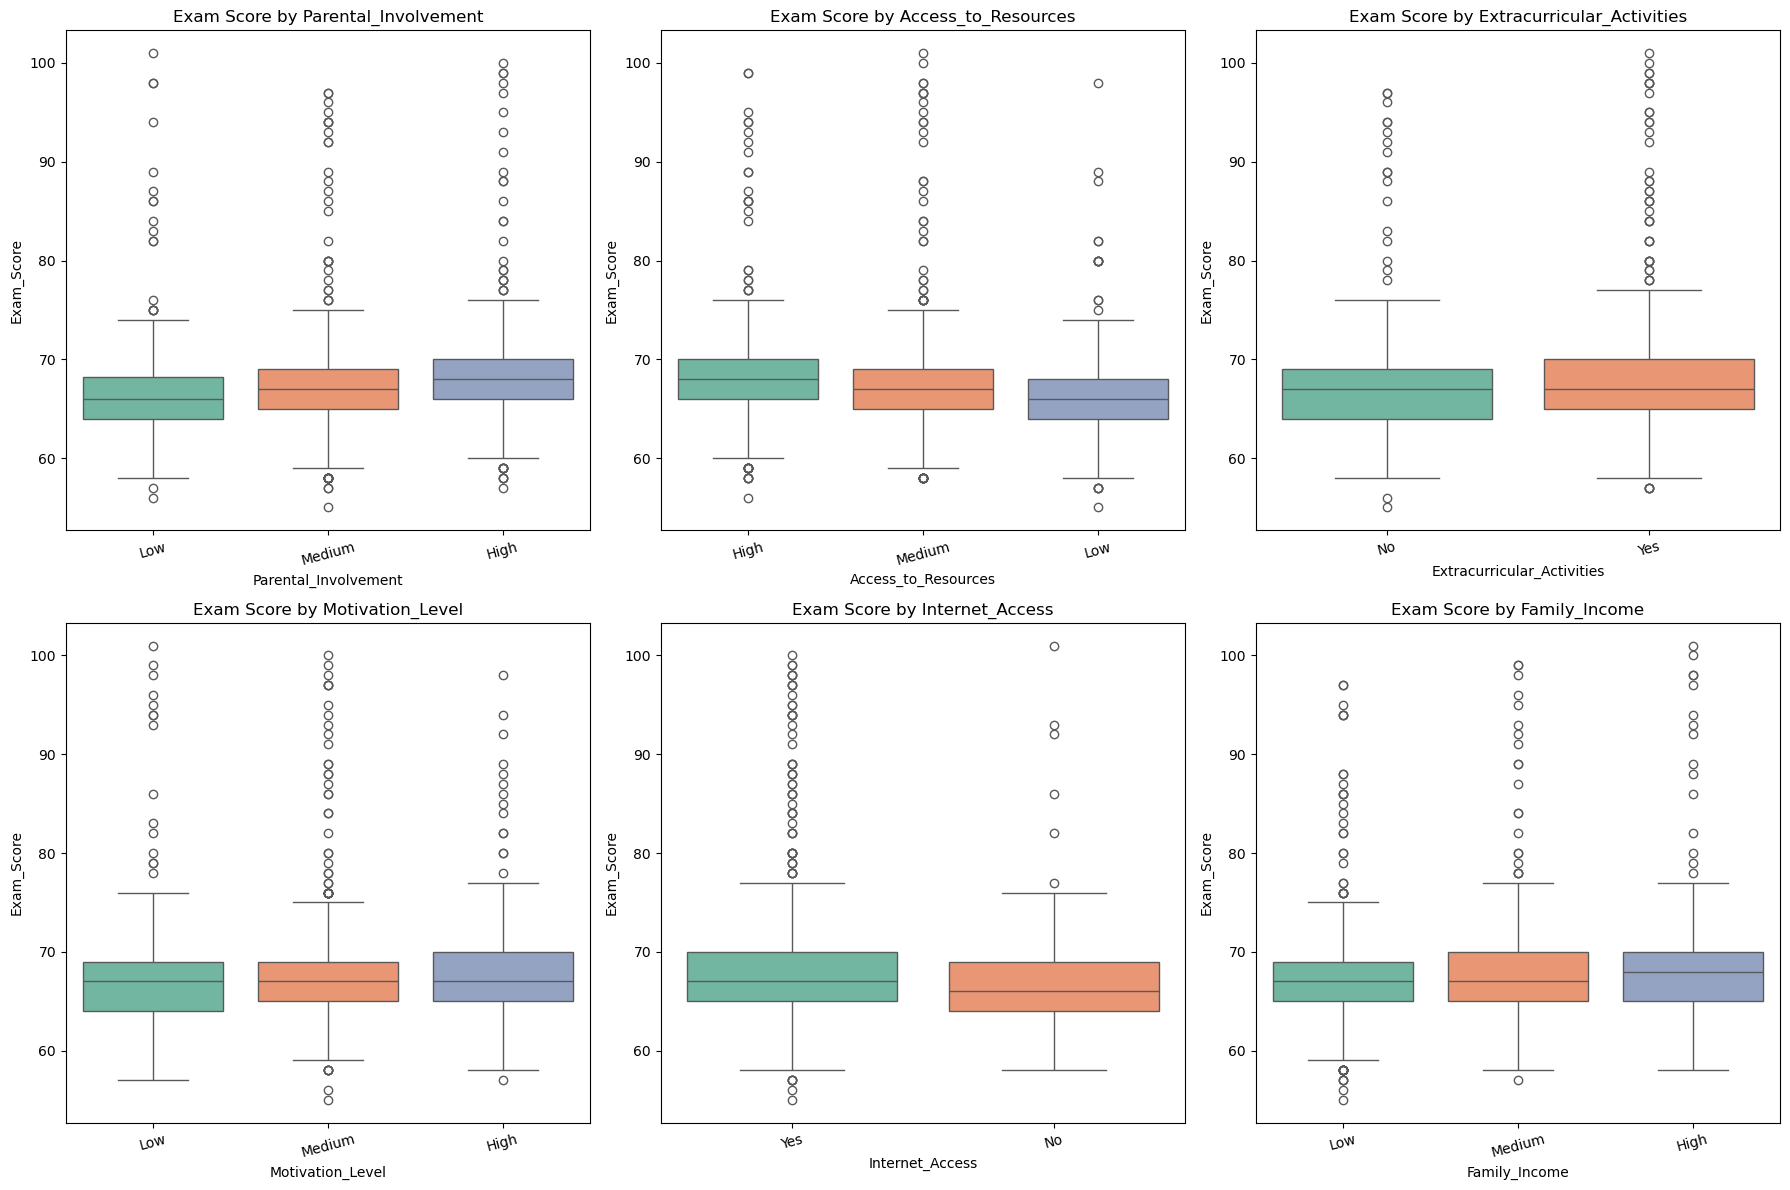

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), catg_coln):
    # Setting hue=col and legend=False fixes the first warning
    # Added hue=col and legend=False to satisfy the new Seaborn requirements
    sns.boxplot(ax=ax, data=df, x=col, y="Exam_Score", hue=col, palette="Set2", legend=False)
    ax.set_title(f"Exam Score by {col}")
    
    # Fixes the tick labels warning by using a FixedLocator implicitly via tick locations
    ax.set_xticks(range(len(df[col].dropna().unique())))
    ax.set_xticklabels(df[col].dropna().unique(), rotation=15)

plt.tight_layout()
plt.show()

# Meaningful Insights from above EDA
Attendance is King: Shows a direct, linear relationship with Exam_Score—higher attendance means steadily better grades.

Study Hours Paradox: Real score gains scale linearly after 3+ hours. (Note: A tiny subset of students with exactly 0 hours oddly score high, likely due to strong natural baselines).

Sleep Sweet Spot: Scores are highly volatile at 4–5 hours (likely due to erratic late-night cramming) but stabilize into a healthy average around 7–9 hours.

The Internet Advantage: Having Internet_Access provides a clear, distinct shift upward in both median and maximum possible scores.

Extracurricular Boost: Students involved in activities hold a slight, consistent edge over those who aren't.

The Overlap Factors: Features like Motivation_Level, Parental_Involvement, and Family_Income show heavily overlapping spreads. Individually, they don't guarantee high scores; their true impact relies on being paired with solid study and attendance habits.

# Encoding

In [10]:
ordinal_mapping = {
    'Low' : 0,
    'Medium' : 1,
    'High' : 2
}

oe_coln = ["Parental_Involvement","Access_to_Resources","Motivation_Level","Family_Income","Teacher_Quality"]

# Handle Ordinal columns
for col in oe_coln:
    df[col] = df[col].map(ordinal_mapping)

df['Parental_Education_Level'] = df['Parental_Education_Level'].map({'High School' : 0, 'College' : 1, 'Postgraduate' : 2})

In [11]:
# Handle Binary Columns
binary_coln = ["Extracurricular_Activities", "Internet_Access", "Learning_Disabilities"]
for col in binary_coln:
    df[col] = df[col].map({"Yes" : 1, "No" : 0})

In [12]:
# Handle Nominal Columns
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

ohe_coln = catg_coln.drop(oe_coln+binary_coln + ['Parental_Education_Level'])
ohe_coln
ohe_encoded = ohe.fit_transform(df[ohe_coln])
ohe_encoded_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(ohe_coln), index=df.index)
df = pd.concat([df.drop(ohe_coln,axis=1), ohe_encoded_df], axis=1)

exam_score_col = df.pop("Exam_Score")
df.insert(len(df.columns), "Exam_Score", exam_score_col)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 6606
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Hours_Studied                6606 non-null   float64
 1   Attendance                   6606 non-null   float64
 2   Parental_Involvement         6606 non-null   int64  
 3   Access_to_Resources          6606 non-null   int64  
 4   Extracurricular_Activities   6606 non-null   int64  
 5   Sleep_Hours                  6606 non-null   float64
 6   Previous_Scores              6606 non-null   float64
 7   Motivation_Level             6606 non-null   int64  
 8   Internet_Access              6606 non-null   int64  
 9   Tutoring_Sessions            6606 non-null   float64
 10  Family_Income                6606 non-null   int64  
 11  Teacher_Quality              6606 non-null   int64  
 12  Physical_Activity            6606 non-null   float64
 13  Learning_Disabilities  

# Creating Heatmap

<Axes: >

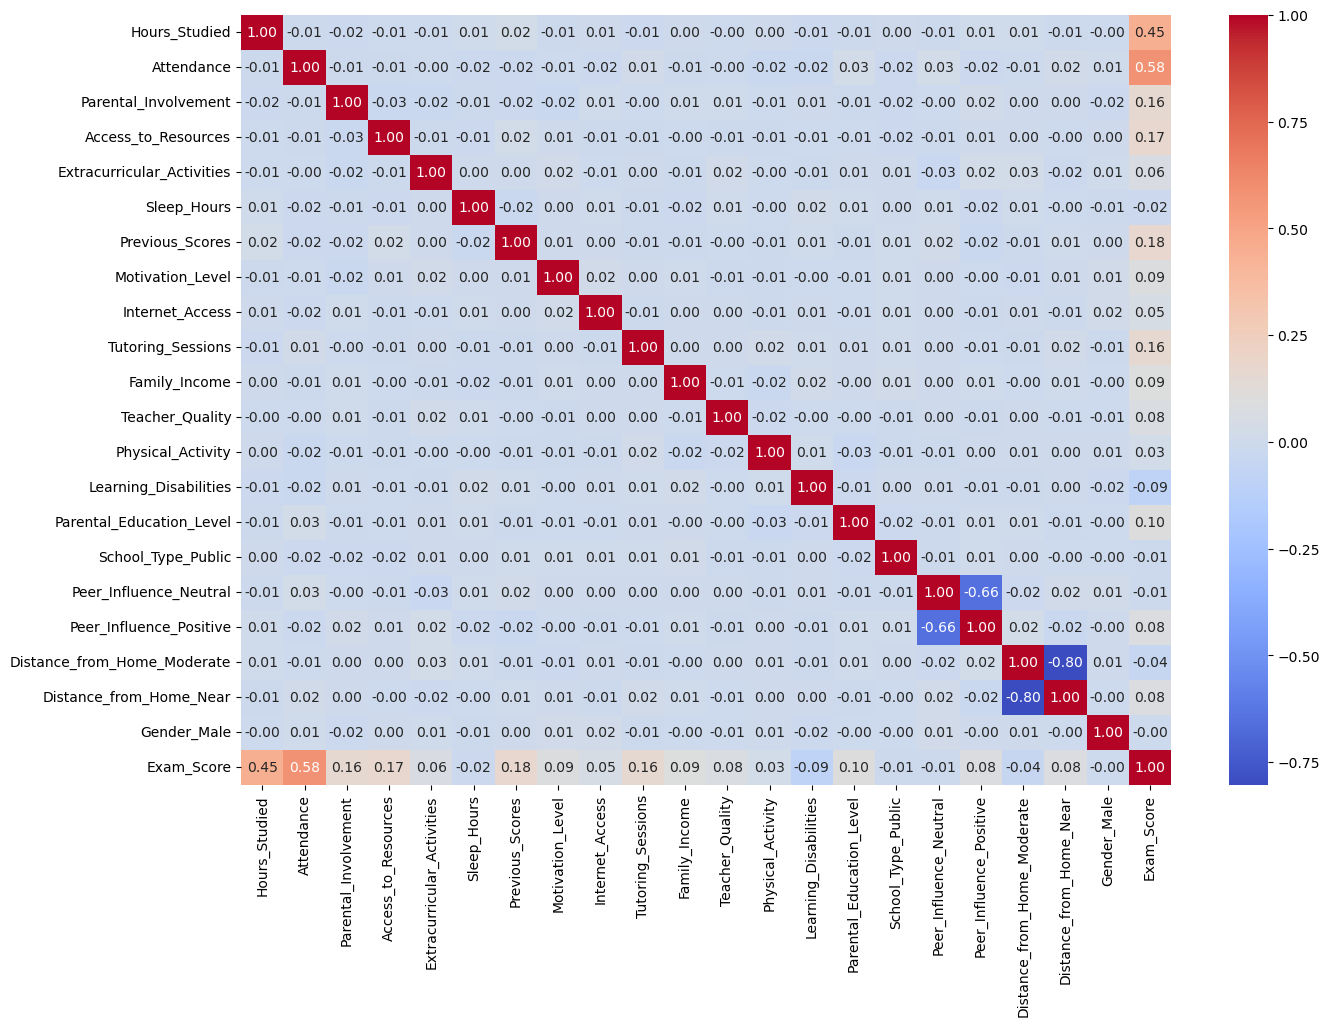

In [13]:
corr_matrix = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Train-Test-Split

In [14]:
# Feature Engineering
df["Hours_Studied_log"] = np.log1p(df["Hours_Studied"])
df["Previous_Scores_log"] = np.log1p(df["Previous_Scores"])

X = df.drop(["Exam_Score",        
    "Gender_Male",        
    "School_Type_Public", 
    "Sleep_Hours",           
    "Distance_from_Home_Moderate",
    "Peer_Influence_Neutral"], axis=1)

y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Linear Regression Model

In [16]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 2. Regularized Model : Lasso

In [17]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


# 3. Regularized Model : Ridge

In [18]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=100)
ridge_model.fit(X_train_scaled, y_train)

,alpha,100
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


# 4. Elasticnet

In [19]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet(alpha=0.01, l1_ratio=0.3)
elastic_model.fit(X_train_scaled, y_train)

,alpha,0.01
,l1_ratio,0.3
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


# 5. XGBoost (Boosting)

In [20]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# 6. Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500, 
    min_samples_split=4, 
    min_samples_leaf=4, 
    max_features='sqrt', 
    max_depth=15, 
    bootstrap=True, 
    random_state=42
)
rf.fit(X_train_scaled, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,15
,min_samples_split,4
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 7. SVR Model

In [22]:
from sklearn.svm import SVR

svr_model = SVR(
    C=0.1, 
    epsilon=0.01, 
    gamma='scale', 
    kernel='linear'
)
svr_model.fit(X_train_scaled, y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,0.1
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


# 8. Voting Regressor

In [23]:
from sklearn.ensemble import VotingRegressor

voting_model = VotingRegressor(estimators=[
    ('lr', lr_model),
    ('rf', rf),
    ('xgb', xgb_model),
    ('svr', svr_model)
])
voting_model.fit(X_train_scaled, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,n_estimators,500
,criterion,'squared_error'


# Model Evaluation

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

models_dict = {
    "Linear Regression": lr_model, 
    "Lasso": lasso_model, 
    "Ridge": ridge_model,
    "ElasticNet": elastic_model,
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "Voting Regressor": voting_model,
    "SVR": svr_model
}

for name, model in models_dict.items():

    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("-" * 45)
    print(f"{name} Model Performance:")
    print("-" * 45)
    print(f"Train - MAE: {mae_train:.2f} | RMSE: {rmse_train:.2f} | R²: {r2_train:.4f}")
    print(f"Test  - MAE: {mae_test:.2f}  | RMSE: {rmse_test:.2f}  | R²: {r2_test:.4f}\n")

---------------------------------------------
Linear Regression Model Performance:
---------------------------------------------
Train - MAE: 0.54 | RMSE: 2.10 | R²: 0.7132
Test  - MAE: 0.49  | RMSE: 1.78  | R²: 0.7725

---------------------------------------------
Lasso Model Performance:
---------------------------------------------
Train - MAE: 0.54 | RMSE: 2.10 | R²: 0.7129
Test  - MAE: 0.50  | RMSE: 1.79  | R²: 0.7709

---------------------------------------------
Ridge Model Performance:
---------------------------------------------
Train - MAE: 0.55 | RMSE: 2.11 | R²: 0.7122
Test  - MAE: 0.51  | RMSE: 1.80  | R²: 0.7676

---------------------------------------------
ElasticNet Model Performance:
---------------------------------------------
Train - MAE: 0.54 | RMSE: 2.10 | R²: 0.7129
Test  - MAE: 0.50  | RMSE: 1.79  | R²: 0.7701

---------------------------------------------
Random Forest Model Performance:
---------------------------------------------
Train - MAE: 0.82 | RMSE: 

# Saving Our Best Model

In [29]:
import joblib
joblib.dump(voting_model, 'voting_model.pkl')

['voting_model.pkl']